In [ ]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt
import pretty_midi
from melody import (build_rolls, pad_rolls, compute_highest_per_instrument,
                    track_lead_voice, segment_phrases,
                    compute_feature_vector, feature_vector_to_array)

# Pomijam AOE1 ponieważ harpie psują wykrywanie głosu prowadzącego (mało nut, dużo szumu)
FILES = [
    'music/Age_of_Empires_2_Menu_Music.mid',
    'music/Battlefield_2_Menu_Music.mid',
    'music/Queen - Bohemian Rhapsody.mid',
    'music/Never-Gonna-Give-You-Up-1.mid',
]

FS                   = 100
MIN_NOTES            = 10
MIN_PITCH            = 48
MIN_ENERGY_PER_FRAME = 10
SWITCH_N             = 3
MIN_REST_BEATS       = 2
MIN_PHRASE_NOTES     = 4   # frazy krótsze niż to są odrzucane jako ostinato/szum


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
def run_pipeline(path):
    utwor = pretty_midi.PrettyMIDI(path)
    beats = utwor.get_beats()
    beat_frames = (beats * FS).astype(int)
    rolls, instruments = build_rolls(utwor, fs=FS, min_notes=MIN_NOTES)
    padded, max_len = pad_rolls(rolls)
    beat_frames_clipped = np.clip(beat_frames, 0, max_len)
    n_windows = len(beat_frames_clipped) - 1
    n_inst = len(padded)
    highest = compute_highest_per_instrument(padded, beat_frames_clipped, MIN_PITCH, MIN_ENERGY_PER_FRAME)
    _, lead_pitch = track_lead_voice(highest, n_windows, n_inst, SWITCH_N)
    phrases = segment_phrases(lead_pitch, min_rest_beats=MIN_REST_BEATS)
    phrases = [p for p in phrases if len(p) >= MIN_PHRASE_NOTES]
    return lead_pitch, phrases

results = {}
for file_path in FILES:
    name = os.path.splitext(os.path.basename(file_path))[0]
    lead_pitch, phrases = run_pipeline(file_path)
    results[name] = compute_feature_vector(lead_pitch, phrases)
    active = sum(1 for p in lead_pitch if p is not None)
    print(f"{name}: {len(lead_pitch)} beatów, {active} aktywnych, {len(phrases)} fraz (po filtrze)")


Age_of_Empires_Menu_Music: 101 beatów, 71 aktywnych, 2 fraz (po filtrze)
Age_of_Empires_2_Menu_Music: 132 beatów, 123 aktywnych, 4 fraz (po filtrze)
Battlefield_2_Menu_Music: 192 beatów, 138 aktywnych, 6 fraz (po filtrze)
Queen - Bohemian Rhapsody: 484 beatów, 447 aktywnych, 10 fraz (po filtrze)
Never-Gonna-Give-You-Up-1: 407 beatów, 340 aktywnych, 12 fraz (po filtrze)


In [21]:
SCALAR_KEYS = ['interval_entropy', 'melodic_redundancy', 'step_leap_ratio',
               'pitch_range', 'avg_phrase_length']

names = list(results.keys())
col_w = 12
header = f"{'Metryka':<25}" + ''.join(f"{n:>{col_w}}" for n in names)
print(header)
print('-' * len(header))
for key in SCALAR_KEYS:
    row = f"{key:<25}" + ''.join(f"{results[n][key]:>{col_w}.3f}" for n in names)
    print(row)


Metryka                  Age_of_Empires_Menu_MusicAge_of_Empires_2_Menu_MusicBattlefield_2_Menu_MusicQueen - Bohemian RhapsodyNever-Gonna-Give-You-Up-1
-------------------------------------------------------------------------------------------------------------------------------------------------------
interval_entropy                2.419       3.537       3.216       4.533       3.299
melodic_redundancy              0.394       0.366       0.543       0.557       0.588
step_leap_ratio                10.000       6.933       7.667       2.364       2.866
pitch_range                    15.000      36.000      33.000      40.000      36.000
avg_phrase_length              32.000      30.750      27.000      44.700      28.667


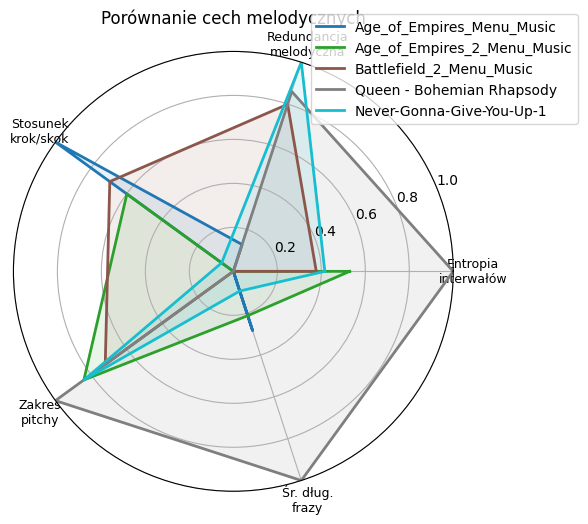

In [22]:
labels = ['Entropia\ninterwałów', 'Redundancja\nmelodyczna', 'Stosunek\nkrok/skok',
          'Zakres\npitchy', 'Śr. dług.\nfrazy']
names = list(results.keys())
n_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]

data = {name: [results[name][k] for k in SCALAR_KEYS] for name in names}
mins = np.min([data[n] for n in names], axis=0)
maxs = np.max([data[n] for n in names], axis=0)
rng  = np.where(maxs - mins == 0, 1, maxs - mins)

colors = plt.cm.tab10(np.linspace(0, 1, len(names)))
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
for (name, vals), color in zip(data.items(), colors):
    normed = ((np.array(vals) - mins) / rng).tolist()
    normed += normed[:1]
    ax.plot(angles, normed, color=color, linewidth=2, label=name)
    ax.fill(angles, normed, color=color, alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('Porównanie cech melodycznych', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


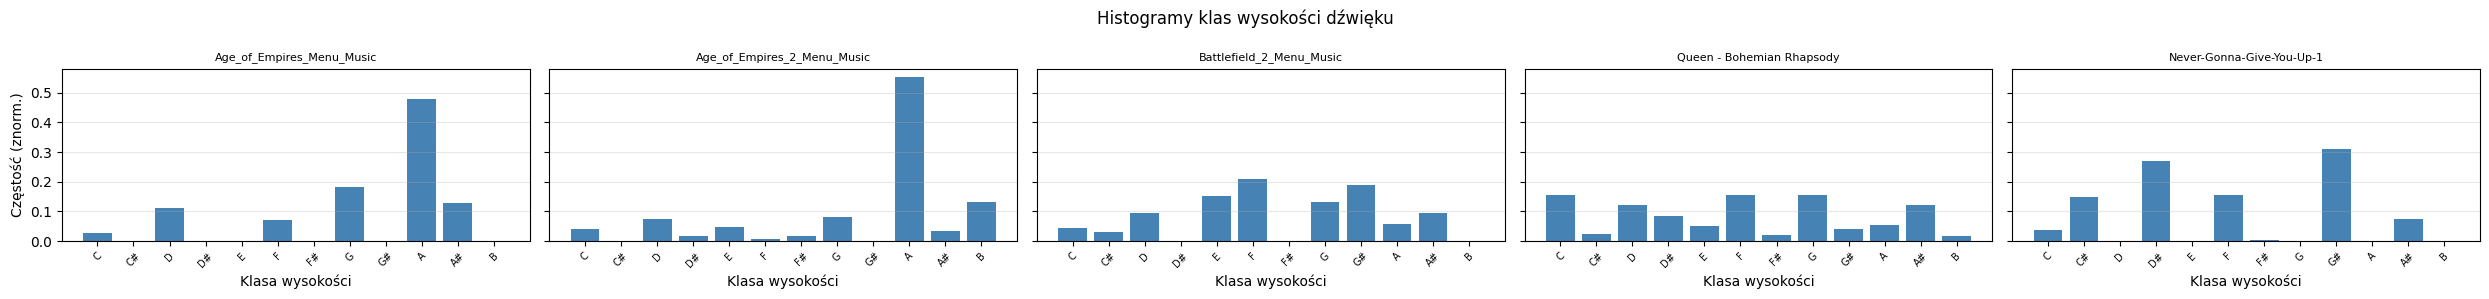

In [23]:
NOTES = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
names = list(results.keys())
fig, axes = plt.subplots(1, len(names), figsize=(5 * len(names), 3), sharey=True)
if len(names) == 1:
    axes = [axes]
for ax, name in zip(axes, names):
    ax.bar(NOTES, results[name]['pc_histogram'], color='steelblue')
    ax.set_title(name, fontsize=8)
    ax.set_xlabel('Klasa wysokości')
    ax.tick_params(axis='x', labelsize=7, rotation=45)
    ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('Częstość (znorm.)')
plt.suptitle('Histogramy klas wysokości dźwięku')
plt.tight_layout()
plt.show()


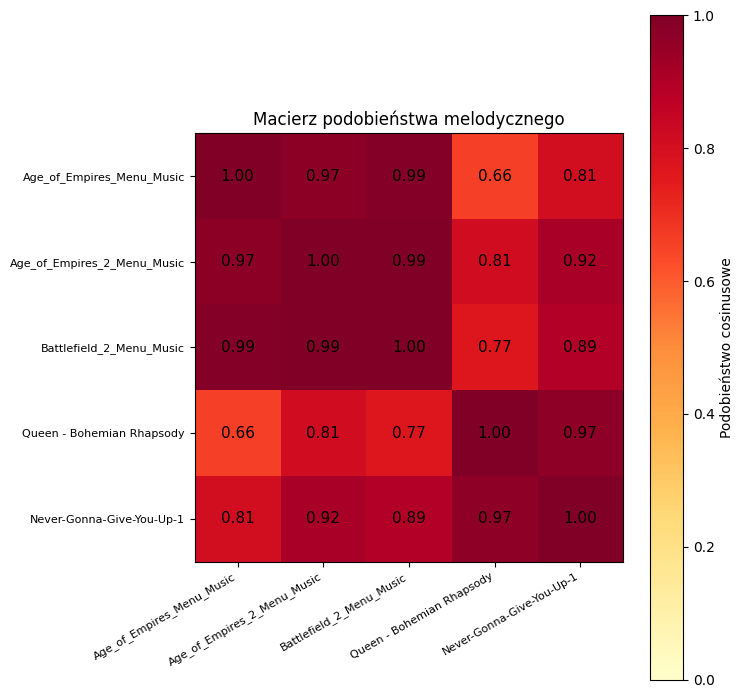

Age_of_Empires_Menu_Music vs Age_of_Empires_2_Menu_Music: 0.972
Age_of_Empires_Menu_Music vs Battlefield_2_Menu_Music: 0.985
Age_of_Empires_Menu_Music vs Queen - Bohemian Rhapsody: 0.657
Age_of_Empires_Menu_Music vs Never-Gonna-Give-You-Up-1: 0.806
Age_of_Empires_2_Menu_Music vs Battlefield_2_Menu_Music: 0.994
Age_of_Empires_2_Menu_Music vs Queen - Bohemian Rhapsody: 0.811
Age_of_Empires_2_Menu_Music vs Never-Gonna-Give-You-Up-1: 0.916
Battlefield_2_Menu_Music vs Queen - Bohemian Rhapsody: 0.769
Battlefield_2_Menu_Music vs Never-Gonna-Give-You-Up-1: 0.892
Queen - Bohemian Rhapsody vs Never-Gonna-Give-You-Up-1: 0.968


In [24]:
names = list(results.keys())
vecs  = np.array([feature_vector_to_array(results[n]) for n in names])

norms = np.linalg.norm(vecs, axis=1, keepdims=True)
vecs_normed = vecs / np.where(norms == 0, 1, norms)
sim_matrix = vecs_normed @ vecs_normed.T

fig, ax = plt.subplots(figsize=(max(4, len(names) * 1.5), max(4, len(names) * 1.5)))
im = ax.imshow(sim_matrix, vmin=0, vmax=1, cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Podobieństwo cosinusowe')
ax.set_xticks(range(len(names)))
ax.set_yticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha='right', fontsize=8)
ax.set_yticklabels(names, fontsize=8)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f'{sim_matrix[i, j]:.2f}', ha='center', va='center', fontsize=11)
ax.set_title('Macierz podobieństwa melodycznego')
plt.tight_layout()
plt.show()

for i in range(len(names)):
    for j in range(i + 1, len(names)):
        print(f"{names[i]} vs {names[j]}: {sim_matrix[i, j]:.3f}")
